# Hands-on 3 — Enhanced sampling

Today we put five ideas into practice, on the two-dimensional model system of day 1:

1. **Block analysis**
2. **Adaptive umbrella sampling**
3. **Metadynamics**
4. **Markov-chain Monte Carlo**
5. **Replica exchange**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)

## 0. The model system

We use the same potential energy surface of day 1,

$$U(x,y) = h\,(x^2-1)^2 \;+ \tfrac12 k\,(y-x)^2$$

Let's recall that:
* it has two minima: $(-1,-1)$ and $(1,1)$
* the barrier's height is $h$;

We work as usual in units where $k_BT = 1$ and $m =1$.

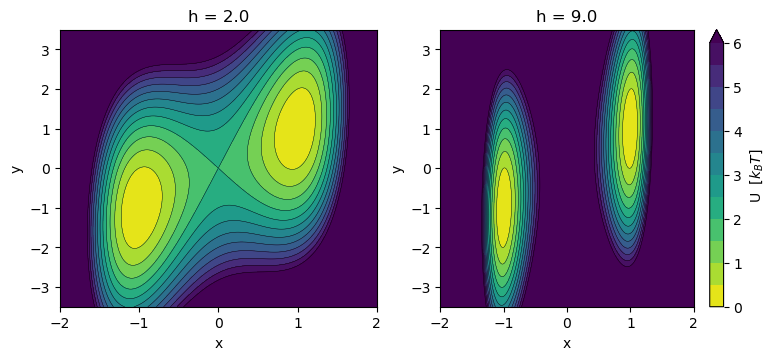

In [2]:
KT = 1.0                    # temperature
K = 1.0                     # spring constant
H_low, H_high = 2.0, 9.0    # barrier heights (easy and hard)

def U(x, y, h=H_high, k=K):
    return h * (x**2 - 1.0)**2 + 0.5 * k * (y - x)**2

def force(r, h=H_high, k=K):
    """Force on a particle at r = (x, y). Works on a single (2,) vector, or on
    an array of them of shape (..., 2)."""
    x, y = r[..., 0], r[..., 1]
    return np.stack([-4 * h * x * (x**2 - 1) + k * (y - x),
                     -k * (y - x)], axis=-1)

# plot the potential energy surface for the two settings we will use
xg, yg = np.linspace(-2, 2, 300), np.linspace(-3.5, 3.5, 300)
Xg, Yg = np.meshgrid(xg, yg)
levels = np.linspace(0, 6.0, 13)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.6))
for k_, h_, in enumerate([H_low,H_high]):
    cf = ax[k_].contourf(Xg, Yg, U(x=Xg, y=Yg, h=h_), levels=levels, cmap="viridis_r", extend="max")
    ax[k_].contour(Xg, Yg, U(x=Xg, y=Yg, h=h_), levels=levels, colors="k", linewidths=0.3)
    ax[k_].set(xlabel="x", ylabel="y", title=f"h = {h_:.1f}")
fig.colorbar(cf, ax=ax[1], label="U  [$k_BT$]")
plt.show()

### The dynamics: the Langevin thermostat

We sample the **canonical** ensemble with the Langevin thermostat of day 1:

In [3]:
DT  = 0.02       # time step
TAU = 1.0        # thermostat relaxation time (day 1: gamma = 1 / tau)

def langevin(v, T0, dt, tau, m=1.0):
    """Local and stochastic: partially forget the velocity, partially redraw it."""
    c = np.exp(-dt / tau)                      # friction, gamma = 1 / tau
    return c * v + np.sqrt((1 - c**2) * T0 / m) * rng.standard_normal(np.shape(v))

def run_md(r, v, force, dt=DT, nsteps=10000, kT=KT, tau=TAU, m=1.0):
    """Velocity Verlet followed by one Langevin thermostat step.
    r and v are (2,) vectors for one particle; giving arrays of shape (R, 2) propagates
    R independent walkers at once.

    Returns:
        the time points, shape (nsteps+1,)
        the particle trajectory, shape (nsteps+1, *shape(r)),
    """
    r, v = np.array(r, dtype=float), np.array(v, dtype=float)
    rs = np.zeros((nsteps + 1,) + r.shape)
    rs[0], f = r, force(r)
    for i in range(1, nsteps + 1):
        v = v + 0.5 * dt * f / m            # half kick
        r = r + dt * v                      # drift
        f = force(r)                        # new force
        v = v + 0.5 * dt * f / m            # half kick
        v = langevin(v, kT, dt, tau, m)     # thermostat
        rs[i] = r
    ts = np.arange(nsteps + 1) * dt
    return ts, rs

### The collective variable: $s = x$

Our CV will be the **first coordinate**, $s(x,y) = x$. The corresponding probability distribution is:

\begin{align*}
\mathcal{P}(s) &= \int\!\mathrm dx\,dy\; \frac{1}{Z}e^{-\beta U(x,\,y)} \delta(x - s) \\
&= \frac{1}{Z} \int\!\mathrm dy\; e^{-\beta U(s,\,y)} \\
&= \frac{1}{Z} e^{-\beta  h(s^2-1)^2} \int\!\mathrm dy\;e^{-\frac{\beta k}{2}(y-s)^2} \\
&\propto e^{-\beta  h(s^2-1)^2}
\end{align*}

Therefore the free energy as a function of the CV is:

\begin{align*}
F(s) &= -\frac{1}{\beta} \log \mathcal{P}(s) = h(s^2-1)^2 + \text{const}
\end{align*}

# Part 1 - Errors of time averages

We ran a trajectory and computed an average, **what is the error bar?**

Let's reason on the variable $x$ and its average, $\langle x\rangle$. From the symmetry of the landscape we know that the ground-truth value is $\langle x\rangle = 0$.

### First run

We run **50 independent walkers at once** using the `langevin` functions (it accepts arrays!). We will use:

* walker 0 as "the simulation we actually ran",
* all 50 walkers as a **ground truth**: the spread of the 50 estimates of $\langle x\rangle$ is,
  by definition, the error bar we are trying to estimate.

First the "easy" setting in which the barrier is low:

In [4]:
R, N = 50, 10**5       # 50 walkers, 100k steps each

f_easy = lambda r: force(r=r, h=H_low, k=K)     # easy barrier
start_r = rng.uniform(-1.0, 1.0, size=(R, 2))   # 50 independent random starts
start_v = np.zeros((R, 2))                      # start at rest

ts, traj = run_md(r=start_r, v=start_v, force=f_easy, dt=DT, nsteps=N)

ts = ts[1000:]            # discard equilibration part
traj = traj[1000:]        

X = traj[:, :, 0]         # the CV of every walker: shape (nsteps+1, R)
x_obs = X[:, 0]           # the "observed" simulation
print(f"trajectory array: {traj.shape},  {traj.nbytes/1e6:.0f} MB")
njumps = np.sum(np.sign(x_obs[1:]) != np.sign(x_obs[:-1]))
print(f"walker 0 crossed the barrier {njumps} times")

trajectory array: (99001, 50, 2),  79 MB
walker 0 crossed the barrier 151 times


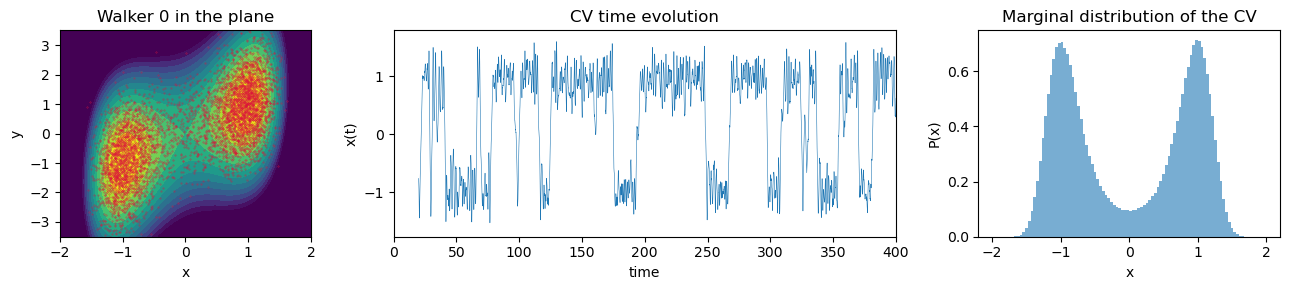

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3), width_ratios=[1, 2, 1.2])

ax[0].contourf(Xg, Yg, U(x=Xg, y=Yg, h=H_low), levels=np.linspace(0, 6, 13), cmap="viridis_r", extend="max")
ax[0].plot(traj[::20, 0, 0], traj[::20, 0, 1], ".", color="crimson", ms=0.5)
ax[0].set(xlabel="x", ylabel="y", title="Walker 0 in the plane", xlim=(-2, 2), ylim=(-3.5, 3.5))

ax[1].plot(ts, x_obs, lw=0.4)
ax[1].set(xlabel="time", ylabel="x(t)", title="CV time evolution", xlim=(0, 400))

# the marginal distribution of the CV must follow exp(-beta F)
ax[2].hist(X.ravel(), bins=100, range=(-2, 2), density=True, alpha=0.6)
ax[2].set(xlabel="x", ylabel="P(x)", title="Marginal distribution of the CV")
plt.tight_layout()

In the next cell we compute the average and its **naive** error bar, the one the central limit theorem
gives for $N$ *independent* samples:

$$\bar x = \frac1N\sum_{i=1}^N x_i, \qquad \sigma^2_{\bar x} \overset{?}{=} \frac{\mathrm{Var}[x]}{N}$$

In [6]:
naive_err = x_obs.std(ddof=1) / np.sqrt(N + 1)
true_err  = X.mean(axis=0).std(ddof=1)        # spread of the 50 independent estimates

print(f"<x> from walker 0       = {x_obs.mean():+.4f}  +-  {naive_err:.4f}   (naive)")
print(f"true error (50 walkers) = {true_err:.4f}")
print(f"\nthe naive error bar is {true_err/naive_err:.0f} times too small!")

<x> from walker 0       = +0.0947  +-  0.0029   (naive)
true error (50 walkers) = 0.0841

the naive error bar is 29 times too small!


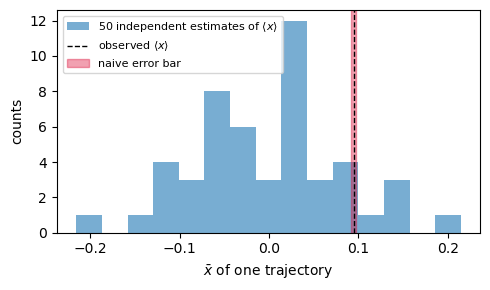

In [7]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(X.mean(axis=0), bins=15, alpha=0.6, label="50 independent estimates of $\\langle x\\rangle$")
ax.axvline(x_obs.mean(), linestyle="--", color="k", lw=1, label="observed $\\langle x\\rangle$")
ax.axvspan(x_obs.mean()-naive_err, x_obs.mean()+naive_err, color="crimson", alpha=0.4, label="naive error bar")
ax.set(xlabel="$\\bar{x}$ of one trajectory", ylabel="counts")
ax.legend(fontsize=8)
plt.tight_layout()

The naive error bar is strongly underestimated: it says that our $\langle x\rangle$ sits many error bars away from the exact value $0$. The reason is that the formula $\sigma^2_{\bar O} = \mathrm{Var}[O]/N$ holds for **independent** samples, and consecutive points of a trajectory are anything but independent.

### The autocorrelation function

The degree of correlation in time is quantified by

$$C(\tau) = \frac{\langle (x_i - \bar x)(x_{i+\tau} - \bar x)\rangle}{\langle (x_i-\bar x)^2\rangle}$$

which for a stationary dynamics depends only on the lag $\tau$.

In [8]:
def acf(a, nlags):
    """Normalised autocorrelation function C(tau), for tau = 0 ... nlags-1."""
    a = a - a.mean()
    c = np.array([
            np.mean(a[:len(a)-lag] * a[lag:]) 
            for lag in range(nlags)
        ])
    acf = c / c[0]
    return acf

nlags = 5000
c_x  = acf(a=x_obs, nlags=nlags)

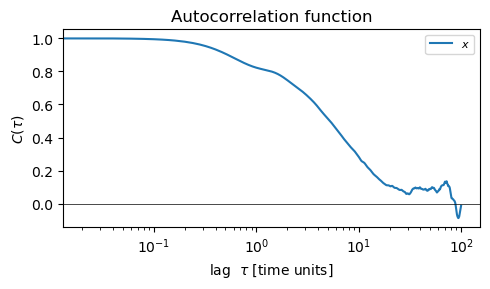

In [9]:
fig, ax = plt.subplots(figsize=(5, 3))
lags = np.arange(nlags) * DT
ax.plot(lags, c_x, label=f"$x$")
ax.axhline(0, color="k", lw=0.5)
ax.set(xlabel="lag  $\\tau$ [time units]", ylabel="$C(\\tau)$", xscale="log",
       title="Autocorrelation function")
ax.legend(fontsize=8)
plt.tight_layout()

### Block analysis

Split the trajectory into $B$ non-overlapping blocks of length $N_b$ and average inside each block:

$$\bar x_j = \frac1B \sum_{i \in \text{block } j} x_i \qquad\Longrightarrow\qquad
  \sigma_{\bar x} \simeq \frac{1}{\sqrt{B}}\;\mathrm{std}\big[\{\bar x_j\}\big]$$

If $B$ is large enough the block averages are independent and this estimate is correct. The recipe is to plot the estimate against $N_b$ and look for the **plateau**:

* $N_b$ too small; blocks still correlated and error **underestimated**;
* $N_b$ too large: too few blocks and the estimate is noisy (we also plot its own error bar,
  $\sigma/\sqrt{2(B-1)}$).

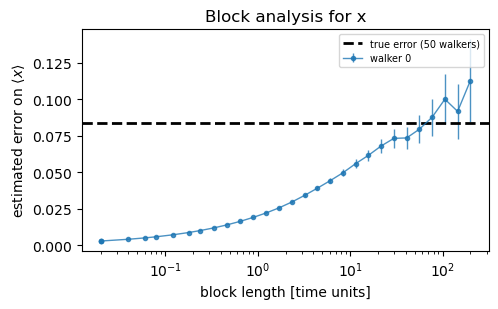

In [ ]:
def block_error(series, blocksize):
    """Error on the mean of series, from non-overlapping blocks. 
    Returns (error, error on the error)."""
    B = ...   # number of blocks

    # average inside each block
    means = np.zeros(B)
    for j in range(B):
        means[j] = ...

    err = ...
    return err, err / np.sqrt(2 * (B - 1))


# block sizes we want to test
blocksizes = np.logspace(0, 4, 30).astype(int)   # from 1 to 10^4 steps

# block analysis for the observable x
x_obs = X[:, 0]
e = np.array([block_error(series=x_obs, blocksize=B) for B in blocksizes])

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.errorbar(blocksizes * DT, e[:, 0], yerr=e[:, 1], lw=1, marker="o", ms=3,
            alpha=0.8, label="walker 0")
ax.axhline(true_err, color="k", ls="--", lw=2, label="true error (50 walkers)")
ax.set(xlabel="block length [time units]", ylabel="estimated error on $\\langle x\\rangle$",
       xscale="log", title="Block analysis for x")
ax.legend(fontsize=7)
plt.tight_layout()

> **Exercises:** 
> - Complete the function `block_error`
> - Can you find a variable that relaxes faster? What is the slowest you can find? Note that every function of $x$ and $y$ is a valid option!
> - Use the slow variable in the block analysis. How does the picture change?
> - Change the value of the barrier. What happens now?

# Part 2 - Metastability and Adaptive Umbrella Sampling

Same code as in Part 1, with two changes: the barrier is now $h = 8$ instead of $2$, and we follow a **single** trajectory.

In [11]:
N = 10**5                                      # 100k steps = 2000 time units

H_high = 8.0
f_hard = lambda r: force(r=r, h=H_high)        # hard barrier
start_r = rng.uniform(-1.0, -1.0, size=2)      # one random start
start_v = np.zeros(2)                          # start at rest

ts, traj = run_md(r=start_r, v=start_v, force=f_hard, dt=DT, nsteps=N)
x_obs = traj[:, 0]                             # the CV along the trajectory

njumps = np.sum(np.sign(x_obs[1:]) != np.sign(x_obs[:-1]))
print(f"the walker crossed the barrier {njumps} times")

the walker crossed the barrier 0 times


### The free energy from a histogram

We estimate $F(s)$ by histogramming the CV: if $n_i$ samples out of $N$ fall in bin $i$, of width
$\Delta$,

$$P_i = \frac{n_i}{N\,\Delta}, \qquad F_i = -k_BT\ln P_i$$

In [12]:
nbins, blocksize = 40, 5000        # 40 bins over the CV, blocks of 5000 steps (plateau of Part 1)

counts, bin_edges = np.histogram(x_obs, bins=nbins, range=(-1.8, 1.8))
centres = 0.5 * (bin_edges[1:] + bin_edges[:-1])
delta = bin_edges[1] - bin_edges[0]
P = counts / (len(x_obs) * delta)
F = np.full_like(P, np.nan)          # empty bins stay nan
F[P > 0] = -KT * np.log(P[P > 0])    # log only ever sees positive values
F = F - np.nanmin(F)

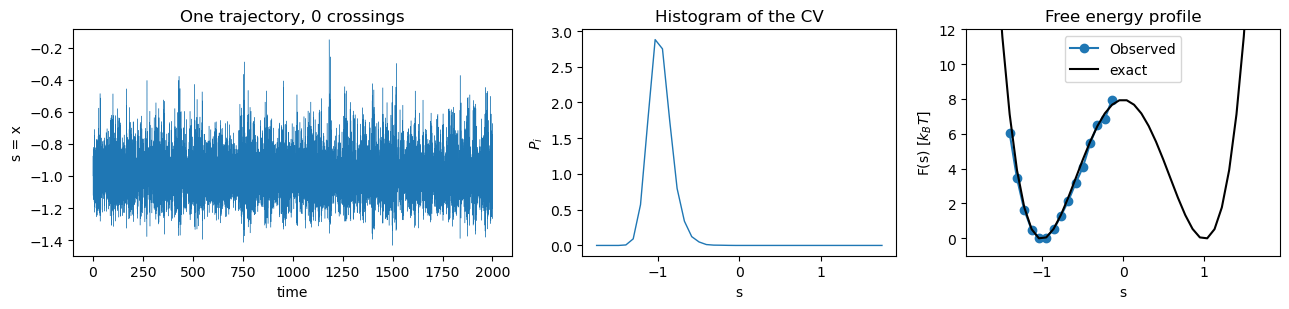

In [13]:
F_ex = H_high * (centres**2 - 1)**2 # exact free energy profile along the CV
F_ex = F_ex - np.min(F_ex)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.2), width_ratios=[1.4, 1, 1])

# plot time evolution of s = x
ax[0].plot(ts, x_obs, lw=0.3)
ax[0].set(xlabel="time", ylabel="s = x", title=f"One trajectory, {njumps} crossings")

# plot the histogram
ax[1].plot(centres, P, "-", lw=1)
ax[1].set(xlabel="s", ylabel="$P_i$", title="Histogram of the CV")

# plot the free energy profile
ax[2].plot(centres, F, 'o-', label="Observed")
ax[2].plot(centres, F_ex - F_ex.min(), "k", lw=1.5, label="exact")
ax[2].set(xlabel="s", ylabel="F(s) [$k_BT$]", ylim=(-1, 1.5 * H_high), title="Free energy profile")
ax[2].legend(loc="upper center")
plt.tight_layout()

The trajectory is clearly not ergodic, and both $P(s)$ and $F(s)$ manifest this.

> **Exercise:** Try to decrease the barrier: is it enough to observe a transition to have a good free energy estimate?

### Umbrella sampling

Add to the potential a bias that depends on the configuration only through the CV,
$U(\mathbf r) \to U(\mathbf r) + B(s(\mathbf r))$. The biased and unbiased free energies are then
related by:

$$\boxed{\,F_b(s) = F(s) + B(s) + \text{const}\,}$$

so the **optimal bias** is the one that makes the biased landscape flat, $B(s) = -F(s)$ (which we do not know). **Adaptive umbrella sampling** builds it iteratively,

$$B^{(k+1)} \;=\; B^{(k)} - F_b^{(k)}$$

where $F_b^{(k)}$ is measured from the histogram of a short run with the bias $B^{(k)}$. One stops
when $F_b$ is flat, i.e. when the bias has stopped changing.

### Representing the bias

The bias depends on the configuration only through the CV, so $B = B(x)$ and it pushes along $x$ only:

$$f^{\rm bias}_x(x) = -\frac{\mathrm d B}{\mathrm d x}, \qquad f^{\rm bias}_y = 0$$

To compute this numerically:
* we start from $B$ tabulated on a grid in $x$
* we differentiate $B$ on the grid by finite differences
* we linearly interpolate between the grid points

Two practical details from the lecture: the histogram is **smoothed** before taking its logarithm, and the update is applied **only where we have enough counts**, so that we fill the region we visited and leave the rest untouched.

In [14]:
edges = np.linspace(-5.0, 5.0, 401)          # grid over the CV
grid = 0.5 * (edges[1:] + edges[:-1])        # bin centres = grid points for the bias
dgrid = grid[1] - grid[0]

def biased_force(B):
    """Total force (physical + bias), ready to be passed to `langevin`.
    B is an array containing samples of the bias potential on a grid 
    with spacing dgrid."""
    fb = -np.gradient(B, dgrid)                     # -dB/dx on the grid
    def total_force(r):
        f = force(r=r)                              # unbiased force
        f[..., 0] += np.interp(r[..., 0], grid, fb) # the bias acts on x only
        return f
    return total_force

### The adaptive loop

30 iterations of 3000 steps each. Each run restarts from the last configuration with new Maxwell–Boltzmann velocities.

We do not use any convergence criterion: we run a fixed number of iterations and judge convergence by looking at the profiles.

In [ ]:
NITER, NMD, NMIN, SMOOTH = 30, 3000, 30, 0.05
inside = np.abs(grid) < 1.4                  # region where we compare profiles
from scipy.ndimage import gaussian_filter1d

B = np.zeros_like(grid)
r = np.array([-1.0, -1.0])
history, traj_aus = [B.copy()], []

for k in range(NITER):
    # 1) short MD with the current bias
    _, rs = run_md(r=r, v=rng.normal(loc=0.0, scale=np.sqrt(KT), size=2),
                   force=biased_force(B=B), dt=DT, nsteps=NMD)
    r = rs[-1]  # starting position for next iteration
    traj_aus.append(rs[1:, 0])

    # 2) biased free energy: histogram of the CV, smoothed
    counts, _ = np.histogram(rs[:, 0], bins=edges)
    p = gaussian_filter1d(counts / counts.sum() / dgrid, SMOOTH / dgrid)

    # we only trust bins with enough samples: the error on F_i goes as 1/sqrt(n_i)
    trusted = counts >= NMIN
    Fb = np.zeros_like(grid)
    Fb[trusted] = -KT * np.log(p[trusted])
    Fb[trusted] = Fb[trusted] - np.max(Fb[trusted])

    # 3) update by -F_b, where we trust it
    update = np.where(trusted, -Fb, 0.0)
    B = B + update
    history.append(B.copy())

traj_aus = np.concatenate(traj_aus)

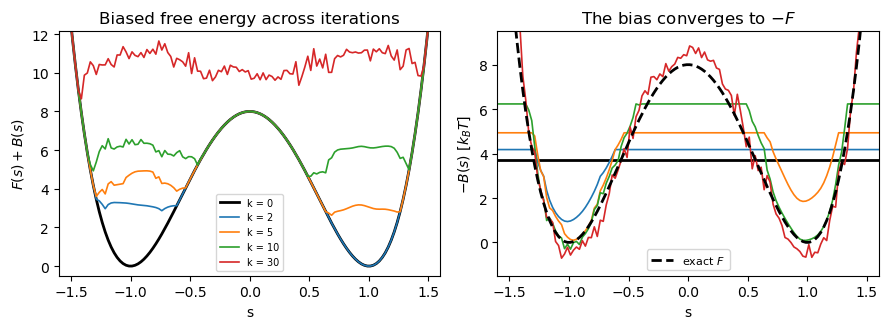

In [16]:
F_exact = H_high * (grid**2 - 1)**2         # reference free energy
show = [j for j in [0, 2, 5, 10, len(history) - 1] if j < len(history)]   # iterations to plot

fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))

# plot the filled free energy at different iterations, and the bias that converges to -F
for j in show:
    style = dict(color="k", lw=2) if j == 0 else dict(lw=1.2)
    filled = F_exact + history[j]
    ax[0].plot(grid, filled, label=f"k = {j}", **style)
    bias_j = history[j]
    bias_j = bias_j - bias_j[inside].mean()  # shift to match F in the inside region
    ax[1].plot(grid, -bias_j + F_exact[inside].mean(), **style)

ax[0].set(xlabel="s", ylabel="$F(s) + B(s)$", xlim=(-1.6, 1.6),
          ylim=(F_exact[inside].min() - 0.5, filled[inside].max() + 0.5),
          title="Biased free energy across iterations")
ax[0].legend(fontsize=7)
ax[1].plot(grid, F_exact, "k--", lw=2, label="exact $F$")
ax[1].set(xlabel="s", ylabel="$-B(s)$ [$k_BT$]", xlim=(-1.6, 1.6),
          ylim=(F_exact[inside].min() - 1.5, F_exact[inside].max() + 1.5),
          title="The bias converges to $-F$")
ax[1].legend(fontsize=8)
plt.tight_layout()

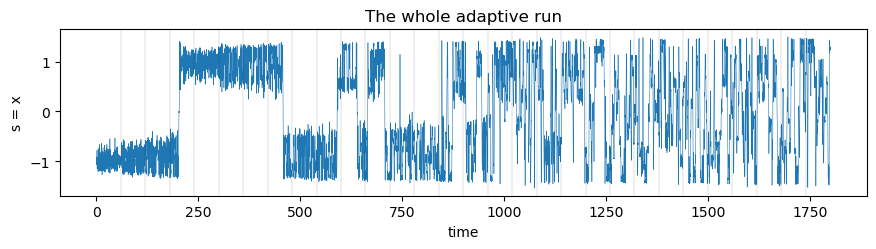

In [17]:
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.plot(np.arange(len(traj_aus)) * DT, traj_aus, lw=0.4)
for k in range(1, NITER):
    ax.axvline(k * NMD * DT, color="k", lw=0.3, alpha=0.3)   # one line per bias update
ax.set(xlabel="time", ylabel="s = x", title="The whole adaptive run")
plt.tight_layout()

> **Question:** Why is the converged $-B$ so rough? How can it be made "smoother"?

### Unbiased averages: reweighting

Any unbiased average is recovered by reweighting each frame with $w_i = e^{+\beta B(s_i)}$:

$$\langle O\rangle = \frac{\big\langle O\,e^{+\beta B}\big\rangle_b}
                          {\big\langle e^{+\beta B}\big\rangle_b}
                   = \frac{\sum_i w_i O_i}{\sum_i w_i}$$

We test it on $O = x^2$, whose exact value can be computed as a reference.

In [18]:
# production run with the bias frozen at its converged value (B from the loop above)
_, rs_prod = run_md(r=r, v=rng.normal(loc=0.0, scale=np.sqrt(KT), size=2),
                    force=biased_force(B=B), dt=DT, nsteps=200_000)
s_prod = rs_prod[:, 0]
weights = np.exp(np.interp(s_prod, grid, B) / KT)          # w = e^{+beta B}
print(f"barrier crossings in the production run: "
      f"{np.sum(np.sign(s_prod[1:]) != np.sign(s_prod[:-1]))}")

# reweighted average
x2_reweight = np.average(s_prod**2, weights=weights)

# exact value: <x^2> = sum_i x_i^2 P_i / sum_i P_i, with P propto exp(-U_i/kT)
s_i = np.linspace(-2, 2, 4001)
p_i = np.exp(-H_high * (s_i**2 - 1)**2 / KT)
x2_exact = np.average(s_i**2, weights=p_i)

print(f"<x^2> in the biased run = {(s_prod**2).mean():.3f}")
print(f"<x^2> reweighted        = {x2_reweight:.3f}")
print(f"<x^2> exact             = {x2_exact:.3f}")

barrier crossings in the production run: 1103
<x^2> in the biased run = 0.722
<x^2> reweighted        = 0.969
<x^2> exact             = 0.964


# Part 3 - Metadynamics

In Metadynamics (Laio & Parrinello, 2002), every $\tau_{\rm dep}$ steps:

$$B(s) \;\longleftarrow\; B(s) + W\exp\!\left(-\frac{(s - s_k)^2}{2\sigma^2}\right)$$

The Gaussian is the "smoothed histogram of a single point": hills accumulate where the system spends time, until the landscape is filled. The parameters are $W$ (height), $\sigma$ (width) and
$\tau_{\rm dep}$ (deposition stride); $W/\tau_{\rm dep}$ is the filling rate.

In [19]:
W, SIGMA, STRIDE, NHILLS = 0.2, 0.3, 500, 200

B_mtd = np.zeros_like(grid)
r = np.array([-1.0, -1.0])
traj_mtd, snaps_mtd = [], {}

for k in range(NHILLS):
    # short MD with the current bias (no equilibration needed)
    _, rs = run_md(r=r, v=rng.normal(loc=0.0, scale=np.sqrt(KT), size=2),
                   force=biased_force(B=B_mtd), dt=DT, nsteps=STRIDE)
    r = rs[-1]
    traj_mtd.append(rs[1:])

    s = r[0]                                                       # current value of the CV
    B_mtd = B_mtd + W * np.exp(-0.5 * ((grid - s) / SIGMA)**2)     # deposit one hill

    if k + 1 in (1, 10, 60, NHILLS):
        snaps_mtd[k + 1] = B_mtd.copy()

traj_mtd = np.concatenate(traj_mtd)
print(f"{np.sum(np.sign(traj_mtd[1:, 0]) != np.sign(traj_mtd[:-1, 0]))} barrier crossings")
print(f"first crossing after {np.argmax(traj_mtd[:, 0] > 0)//STRIDE} hills")

151 barrier crossings
first crossing after 18 hills


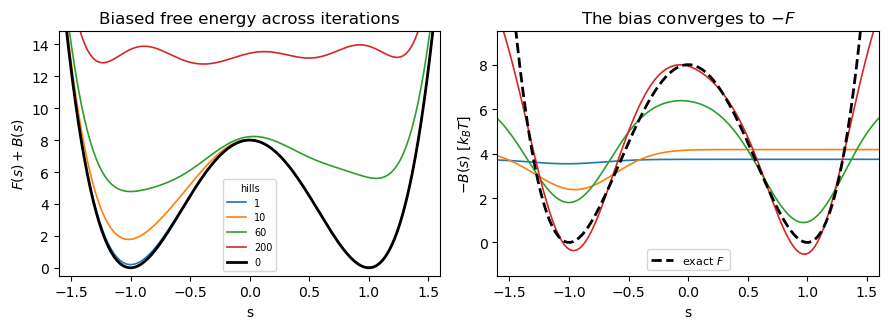

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))

# the same two quantities, with the same conventions, as in the adaptive loop
for k, Bk in snaps_mtd.items():
    filled = F_exact + Bk
    ax[0].plot(grid, filled, lw=1.2, label=f"{k}")
    bias_k = Bk - Bk[inside].mean()        # shift to match F in the inside region
    ax[1].plot(grid, -bias_k + F_exact[inside].mean(), lw=1.2)
ax[0].plot(grid, F_exact, "k", lw=2, label="0")

ax[0].set(xlabel="s", ylabel="$F(s) + B(s)$", xlim=(-1.6, 1.6),
          ylim=(F_exact[inside].min() - 0.5, filled[inside].max() + 0.5),
          title="Biased free energy across iterations")
ax[0].legend(fontsize=7, title="hills", title_fontsize=7)
ax[1].plot(grid, F_exact, "k--", lw=2, label="exact $F$")
ax[1].set(xlabel="s", ylabel="$-B(s)$ [$k_BT$]", xlim=(-1.6, 1.6),
          ylim=(F_exact[inside].min() - 1.5, F_exact[inside].max() + 1.5),
          title="The bias converges to $-F$")
ax[1].legend(fontsize=8)
plt.tight_layout()

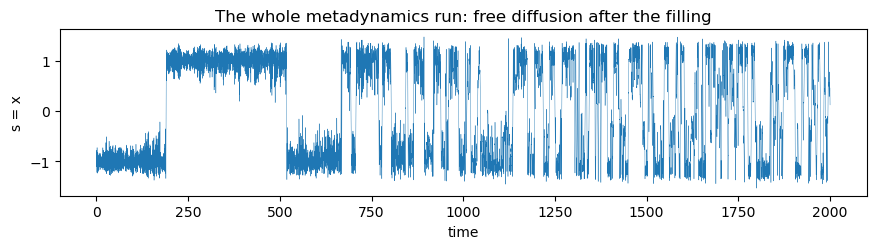

In [21]:
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.plot(np.arange(len(traj_mtd)) * DT, traj_mtd[:, 0], lw=0.3)
ax.set(xlabel="time", ylabel="s = x", title="The whole metadynamics run: free diffusion after the filling")
plt.tight_layout()

> **Exercise 4.** How are the results affected by the choice of the hyperparameters? Specifically, how can we improve the convergence and make the final free energy "flatter"?

# Part 4 - An example with a bad CV

Everything above assumes that $s$ distinguishes the two states. The two minima lie on the diagonal, so
the natural wrong choice is the orthogonal direction,

$$w = \frac{y-x}{\sqrt2}$$

You can show that in this case the free energy is:

$$\,F(w) = k\,w^2 + \text{const}$$

Let's run metadynamics on it, with the same parameters of Part 3, and compare it with the run we already have on the good CV.

In [22]:
def biased_force_w(B):
    """Total force when the bias acts on w = (y - x)/sqrt(2) instead of x."""
    fb = -np.gradient(B, dgrid)                  # -dB/dw on the grid
    def total_force(r):
        w = (r[..., 1] - r[..., 0]) / np.sqrt(2)  # the bad CV
        fw = np.interp(w, grid, fb)               # force along w
        f = force(r=r)
        f[..., 0] -= fw / np.sqrt(2)              # chain rule: dw/dx = -1/sqrt(2)
        f[..., 1] += fw / np.sqrt(2)              #             dw/dy = +1/sqrt(2)
        return f
    return total_force

F_exact_w = K * grid**2                          # exact free energy along the bad CV
inside_w = np.abs(grid) < 3.0                    # region where we compare the profiles


In [23]:
# the metadynamics loop of Part 3, with the bias acting on w instead of x
B_bad = np.zeros_like(grid)
r = np.array([-1.0, -1.0])
traj_bad, snaps_bad = [], {}

for k in range(NHILLS):
    _, rs = run_md(r=r, v=rng.normal(loc=0.0, scale=np.sqrt(KT), size=2),
                   force=biased_force_w(B=B_bad), dt=DT, nsteps=STRIDE)
    r = rs[-1]
    traj_bad.append(rs[1:])

    w = (r[1] - r[0]) / np.sqrt(2)                               # current value of the bad CV
    B_bad = B_bad + W * np.exp(-0.5 * ((grid - w) / SIGMA)**2)   # deposit one hill

    if k + 1 in (1, 10, 60, NHILLS):
        snaps_bad[k + 1] = B_bad.copy()

traj_bad = np.concatenate(traj_bad)
w_mtd = (traj_mtd[:, 1] - traj_mtd[:, 0]) / np.sqrt(2)     # the bad CV along the two runs
w_bad = (traj_bad[:, 1] - traj_bad[:, 0]) / np.sqrt(2)

# transitions between the two states, and range of w explored, in the two runs
cross_good = np.sum(np.sign(traj_mtd[1:, 0]) != np.sign(traj_mtd[:-1, 0]))
cross_bad = np.sum(np.sign(traj_bad[1:, 0]) != np.sign(traj_bad[:-1, 0]))

print(f"bias on s = x (good CV): {cross_good:4d} transitions,"
      f"   w explored in [{w_mtd.min():+.1f}, {w_mtd.max():+.1f}]")
print(f"bias on s = w (bad CV) : {cross_bad:4d} transitions,"
      f"   w explored in [{w_bad.min():+.1f}, {w_bad.max():+.1f}]")

# how good is the reconstructed profile? (both curves shifted to zero mean, as in the plots)
d = (-B_bad - (-B_bad)[inside_w].mean()) - (F_exact_w - F_exact_w[inside_w].mean())
print(f"\nRMSE of the reconstructed F(w) vs the exact k w^2: {np.sqrt(np.mean(d[inside_w]**2)):.2f} kT")


bias on s = x (good CV):  151 transitions,   w explored in [-2.5, +2.6]
bias on s = w (bad CV) :    0 transitions,   w explored in [-3.3, +3.4]

RMSE of the reconstructed F(w) vs the exact k w^2: 0.42 kT


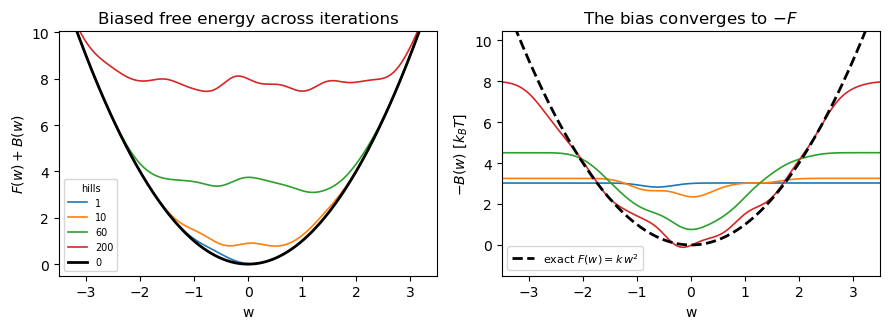

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))

# the same two quantities, with the same conventions, as in the good run of Part 3
for k, Bk in snaps_bad.items():
    filled = F_exact_w + Bk
    ax[0].plot(grid, filled, lw=1.2, label=f"{k}")
    bias_k = Bk - Bk[inside_w].mean()        # shift to match F in the inside region
    ax[1].plot(grid, -bias_k + F_exact_w[inside_w].mean(), lw=1.2)
ax[0].plot(grid, F_exact_w, "k", lw=2, label="0")

ax[0].set(xlabel="w", ylabel="$F(w) + B(w)$", xlim=(-3.5, 3.5),
          ylim=(F_exact_w[inside_w].min() - 0.5, filled[inside_w].max() + 0.5),
          title="Biased free energy across iterations")
ax[0].legend(fontsize=7, title="hills", title_fontsize=7)
ax[1].plot(grid, F_exact_w, "k--", lw=2, label="exact $F(w) = k\\,w^2$")
ax[1].set(xlabel="w", ylabel="$-B(w)$ [$k_BT$]", xlim=(-3.5, 3.5),
          ylim=(F_exact_w[inside_w].min() - 1.5, F_exact_w[inside_w].max() + 1.5),
          title="The bias converges to $-F$")
ax[1].legend(fontsize=8)
plt.tight_layout()

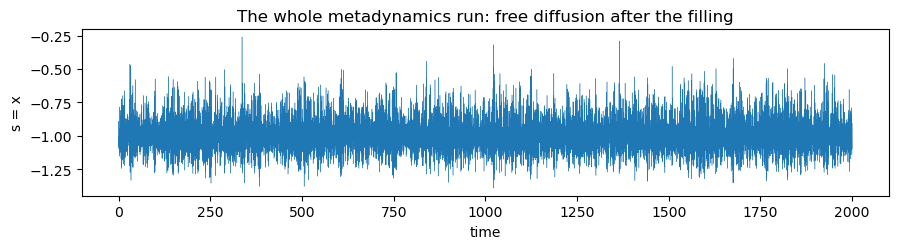

In [25]:
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.plot(np.arange(len(traj_bad)) * DT, traj_bad[:, 0], lw=0.3)
ax.set(xlabel="time", ylabel="s = x", title="The whole metadynamics run: free diffusion after the filling")
plt.tight_layout()

The bias only accelerates what the CV *can see*, and a smooth, converged profile is **not**
evidence that the CV is a good one.

# Part 5 - Markov-chain Monte Carlo

Until now we generated our samples with a **dynamics** (the Langevin integrator). But sampling a
distribution does not require a dynamics: *any* update rule that leaves the target distribution
unchanged will do. This is the idea of **Markov-chain Monte Carlo** (MCMC).

A Markov chain is defined by the probability $T(\mathbf r \to \mathbf r')$ of jumping from one
configuration to another. To sample a target $P(\mathbf r)$ we need $P$ to be **stationary** under $T$:

$$\sum_{\mathbf r} P(\mathbf r)\,T(\mathbf r \to \mathbf r') \;=\; P(\mathbf r')$$

A simple, sufficient (stronger) condition is **detailed balance**, i.e. that each pair of
configurations exchanges probability at the same rate in both directions:

$$P(\mathbf r)\,T(\mathbf r \to \mathbf r') \;=\; P(\mathbf r')\,T(\mathbf r' \to \mathbf r)$$

### The Metropolis rule

Building a $T$ with that property is easy if we split it into a **proposal** and an **acceptance**,

$$T(\mathbf r \to \mathbf r') = \underbrace{A(\mathbf r \to \mathbf r')}_{\text{propose a move}}\;
                                \underbrace{\alpha(\mathbf r \to \mathbf r')}_{\text{accept it or not}}$$

The Metropolis–Hastings choice, for a **symmetric** proposal
($A(\mathbf r \to \mathbf r') = A(\mathbf r' \to \mathbf r)$):

$$\alpha(\mathbf r \to \mathbf r') = \min\left(1,\; \frac{P(\mathbf r')}{P(\mathbf r)}\right)$$

Our proposal will be a small Gaussian displacement, $\mathbf r' = \mathbf r + \delta\,\boldsymbol\xi$, which is clearly symmetric.

> **Exercise:** What is the ratio in the acceptance in the case of Boltzmann distributions? What kind of moves are **always** accepted? Complete the function `metropolis` below.

In [ ]:
STEP = 0.3                       # size of the proposed displacement

def metropolis(r, nsteps, kT=KT, h=H_high, step=STEP):
    """Metropolis random walk sampling exp(-U/kT), starting from r = (x, y).

    Returns:
        the chain, shape (nsteps+1, 2)
        the fraction of accepted moves
    """
    r = np.array(r, dtype=float)

    ...

    rs = np.zeros((nsteps + 1, 2))
    rs[0], nacc = r, 0
    for i in range(1, nsteps + 1):
        r_new = r + step * rng.standard_normal(2)      # symmetric proposal

        ...
       
        if rng.random() < ...:  # Metropolis acceptance
            r = r_new
            ...
            nacc = nacc + 1
        rs[i] = r
    return rs, nacc / nsteps

The only parameter is the step size $\delta$. If $\delta$ is too small almost everything is accepted but we move nowhere; if it is too large almost everything is rejected and we don't move. A common rule of thumb is to tune $\delta$ so that the acceptance is around $0.3$–$0.5$.

Let us first check that the chain really samples the Boltzmann distribution, in the **easy** landscape ($h = 2$) where there is no sampling problem.

In [30]:
NMC = 100_000                                              # 100k Monte Carlo moves

def transitions(x, edge=0.8):
    """Number of times the chain goes from one well to the other (a well is |x| > edge)."""
    side = np.sign(x[np.abs(x) > edge])                    # in which well we are, when in one
    return int(np.sum(side[1:] != side[:-1]))

chain, acc = metropolis(r=[-1.0, -1.0], nsteps=NMC, h=H_low)
x_mc = chain[:, 0]                                         # the CV along the chain

print(f"acceptance = {acc:.2f}")
print(f"the chain went from one well to the other {transitions(x_mc)} times")

acceptance = 0.68
the chain went from one well to the other 587 times


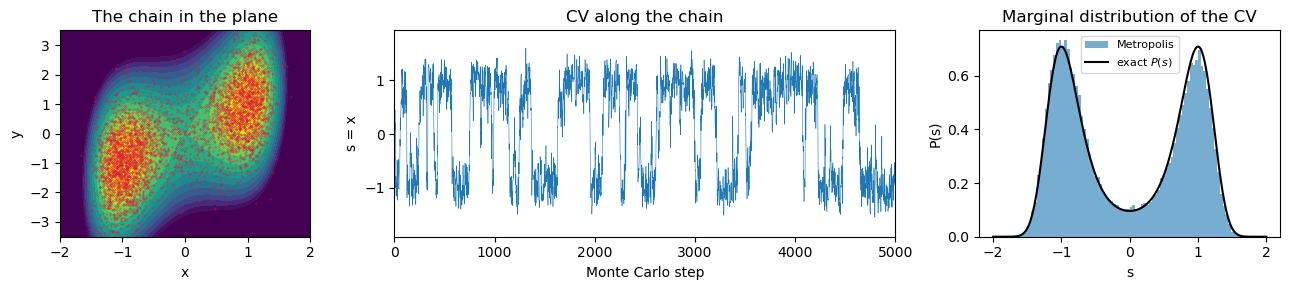

In [31]:
# exact marginal of the CV, P(s) propto exp(-F(s)/kT)
P_ex_low = np.exp(-H_low * (xg**2 - 1)**2 / KT)
P_ex_low = P_ex_low / np.trapezoid(P_ex_low, xg)

fig, ax = plt.subplots(1, 3, figsize=(13, 3), width_ratios=[1, 2, 1.2])

ax[0].contourf(Xg, Yg, U(x=Xg, y=Yg, h=H_low), levels=levels, cmap="viridis_r", extend="max")
ax[0].plot(chain[::20, 0], chain[::20, 1], ".", color="crimson", ms=0.5)
ax[0].set(xlabel="x", ylabel="y", title="The chain in the plane", xlim=(-2, 2), ylim=(-3.5, 3.5))

ax[1].plot(np.arange(NMC + 1), x_mc, lw=0.4)
ax[1].set(xlabel="Monte Carlo step", ylabel="s = x", title="CV along the chain", xlim=(0, 5000))

ax[2].hist(x_mc, bins=100, range=(-2, 2), density=True, alpha=0.6, label="Metropolis")
ax[2].plot(xg, P_ex_low, "k", lw=1.5, label="exact $P(s)$")
ax[2].set(xlabel="s", ylabel="P(s)", title="Marginal distribution of the CV")
ax[2].legend(fontsize=8)
plt.tight_layout()

The histogram falls on the exact curve: a chain of accepted/rejected random displacements samples the
same Boltzmann distribution as the molecular dynamics of Part 1, with no forces and no integrator.

But MCMC is **not** a solution to metastability. Let us repeat exactly the same run on the **hard**
landscape ($h = 9$), the one of Parts 2–4, with a budget of $20\,000$ moves.

In [32]:
NMC_HARD = 20_000                                          # 20k Monte Carlo moves

chain_hard, acc_hard = metropolis(r=[-1.0, -1.0], nsteps=NMC_HARD, h=H_high)
x_mc_hard = chain_hard[:, 0]

print(f"acceptance = {acc_hard:.2f}")
print(f"the chain went from one well to the other {transitions(x_mc_hard)} times")

acceptance = 0.44
the chain went from one well to the other 3 times


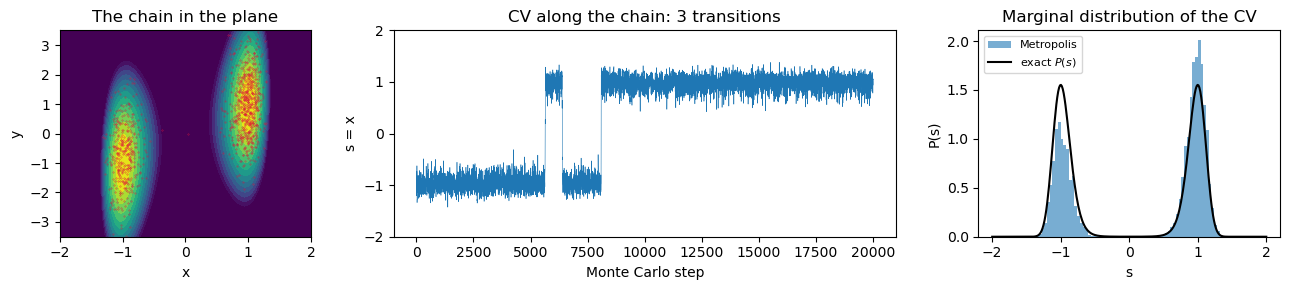

In [33]:
# exact marginal of the CV, now on the hard landscape
P_ex_high = np.exp(-H_high * (xg**2 - 1)**2 / KT)
P_ex_high = P_ex_high / np.trapezoid(P_ex_high, xg)

fig, ax = plt.subplots(1, 3, figsize=(13, 3), width_ratios=[1, 2, 1.2])

ax[0].contourf(Xg, Yg, U(x=Xg, y=Yg, h=H_high), levels=levels, cmap="viridis_r", extend="max")
ax[0].plot(chain_hard[::20, 0], chain_hard[::20, 1], ".", color="crimson", ms=0.5)
ax[0].set(xlabel="x", ylabel="y", title="The chain in the plane", xlim=(-2, 2), ylim=(-3.5, 3.5))

ax[1].plot(np.arange(NMC_HARD + 1), x_mc_hard, lw=0.4)
ax[1].set(xlabel="Monte Carlo step", ylabel="s = x", ylim=(-2, 2),
          title=f"CV along the chain: {transitions(x_mc_hard)} transitions")

ax[2].hist(x_mc_hard, bins=100, range=(-2, 2), density=True, alpha=0.6, label="Metropolis")
ax[2].plot(xg, P_ex_high, "k", lw=1.5, label="exact $P(s)$")
ax[2].set(xlabel="s", ylabel="P(s)", title="Marginal distribution of the CV")
ax[2].legend(fontsize=8)
plt.tight_layout()

# Part 6 - Replica exchange

A different philosophy to observe transitions, rather than modifying the potential, is to **raise the temperature**.

**Replica exchange** runs the two (or more) temperatures **at the same time**, and every now and then propose to **swap their configurations**. The swap is accepted with a Metropolis rule, so that each replica keeps sampling *exactly* its own Boltzmann distribution (but the cold one now gets configurations that were found by the hot one).

### Theory review:

Treat the two replicas as one large system, with configuration $(\mathbf r_1, \mathbf r_2)$. Since they are simulated independently, the joint distribution we are sampling is the product

$$P(\mathbf r_1, \mathbf r_2) \;\propto\; e^{-\beta_1 U(\mathbf r_1)}\; e^{-\beta_2 U(\mathbf r_2)},
  \qquad \beta_1 = 1/k_BT_1 > \beta_2 = 1/k_BT_2$$

The proposed move is the exchange $(\mathbf r_1, \mathbf r_2) \to (\mathbf r_2, \mathbf r_1)$, which is symmetric (proposing the swap and proposing to undo it are the same move). So the Metropolis rule of Part 5 applies, and the acceptance is just the ratio of the joint probabilities after and before:

$$\alpha = \min\Big(1,\; e^{(\beta_1 - \beta_2)\,[\,U(\mathbf r_1) - U(\mathbf r_2)\,]}\Big)$$

> **Question:** In this case, what kind of moves give 100% acceptance probability?

In [ ]:
def replica_exchange(r1, r2, nsweeps, nmd, kT1, kT2, h=H_high, dt=DT):
    """Two Langevin replicas at kT1 < kT2, with one swap attempt every nmd MD steps.

    Returns:
        the two trajectories, shape (nsweeps*nmd, 2) each, at fixed temperature
        the fraction of accepted swaps
    """
    f = lambda r: force(r=r, h=h)
    r1, r2 = np.array(r1, dtype=float), np.array(r2, dtype=float)
    traj1, traj2, nswap = [], [], 0
    for k in range(nsweeps):
        # 1) each replica runs its own MD, at its own temperature
        _, rs1 = run_md(r=r1, v=rng.normal(loc=0.0, scale=np.sqrt(kT1), size=2),
                        force=f, dt=dt, nsteps=nmd, kT=kT1)
        _, rs2 = run_md(r=r2, v=rng.normal(loc=0.0, scale=np.sqrt(kT2), size=2),
                        force=f, dt=dt, nsteps=nmd, kT=kT2)
        r1, r2 = rs1[-1], rs2[-1]
        traj1.append(rs1[1:])
        traj2.append(rs2[1:])

        # 2) propose to swap the two configurations, accept with Metropolis
        arg = (1 / kT1 - 1 / kT2) * (U(r1[0], r1[1], h=h) - U(r2[0], r2[1], h=h))    # log of the acceptance ratio
        if arg >= 0 or rng.random() < np.exp(arg):
            r1, r2 = r2, r1
            nswap += 1
    return np.concatenate(traj1), np.concatenate(traj2), nswap / nsweeps

In [ ]:
KT_HOT, NMD_SWAP = 3.0, 500      # kT of the hot replica, MD steps between two swap attempts
NSWEEP = N // NMD_SWAP           # same number of MD steps as the single trajectory of Part 2

traj_cold, traj_hot, p_swap = replica_exchange(r1=[-1.0, -1.0], r2=[-1.0, -1.0],
                                               nsweeps=NSWEEP, nmd=NMD_SWAP,
                                               kT1=KT, kT2=KT_HOT)
x_cold, x_hot = traj_cold[:, 0], traj_hot[:, 0]

print(f"{NSWEEP * NMD_SWAP} MD steps per replica, one swap attempt every {NMD_SWAP} steps")
print(f"accepted swaps         : {p_swap:.2f}\n")
print(f"transitions, plain MD  : {transitions(x_obs):4d}   (kT = {KT}, Part 2)")
print(f"transitions, cold repl.: {transitions(x_cold):4d}   (kT = {KT})")
print(f"transitions, hot repl. : {transitions(x_hot):4d}   (kT = {KT_HOT})")

100000 MD steps per replica, one swap attempt every 500 steps
accepted swaps         : 0.46

transitions, plain MD  :    0   (kT = 1.0, Part 2)
transitions, cold repl.:   51   (kT = 1.0)
transitions, hot repl. :  189   (kT = 3.0)


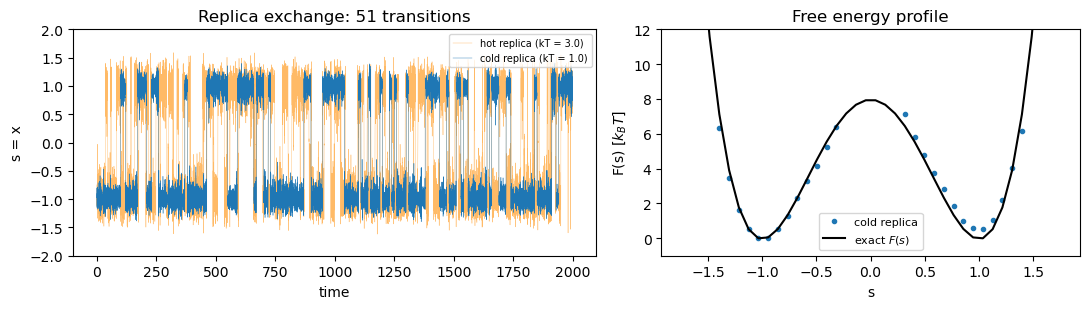

In [ ]:
# free energy from the cold replica, which samples the correct Boltzmann distribution at kT = 1
counts_re, edges_re = np.histogram(x_cold, bins=40, range=(-1.8, 1.8), density=True)
centres_re = 0.5 * (edges_re[1:] + edges_re[:-1])
F_re = np.where(counts_re > 0, -KT * np.log(np.where(counts_re > 0, counts_re, 1)), np.nan)
F_ex_re = H_high * (centres_re**2 - 1)**2

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2), width_ratios=[1.5, 1.2])

t_re = np.arange(len(x_cold)) * DT             # the run is 2000 time units long, as in Part 2

ax[0].plot(t_re, x_hot, lw=0.3, color="darkorange", alpha=0.6,
           label=f"hot replica (kT = {KT_HOT})")
ax[0].plot(t_re, x_cold, lw=0.3, color="C0", label=f"cold replica (kT = {KT})")
ax[0].set(xlabel="time", ylabel="s = x", ylim=(-2, 2),
          title=f"Replica exchange: {transitions(x_cold)} transitions")
ax[0].legend(fontsize=7, loc="upper right")

ax[1].plot(centres_re, F_re - np.nanmin(F_re), "o", ms=3, label="cold replica")
ax[1].plot(centres_re, F_ex_re - F_ex_re.min(), "k", lw=1.5, label="exact $F(s)$")
ax[1].set(xlabel="s", ylabel="F(s) [$k_BT$]", ylim=(-1, 1.5 * H_high), title="Free energy profile")
ax[1].legend(fontsize=8)
plt.tight_layout()

Note however that the **top** of the barrier is still essentially never visited at $k_BT = 1$ (the bins around $s = 0$ are empty or very noisy): replica exchange restores the ergodicity between the states, but it does not flatten the landscape the way the bias of Parts 2–3 does.

> **Exercise:** Raise `KT_HOT` to $6$ and then to $10$. What happens to the swap acceptance, and to the number of transitions of the *cold* one?